# Import Dataset

In [15]:
# Import California Housing dataset and split it into train, validation, and test sets.
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing(as_frame=True)
housing_df = housing.frame.copy()

train_df, test_df = train_test_split(housing_df, test_size=0.2, random_state=42)
train_df, validation_df = train_test_split(train_df, test_size=0.2, random_state=42)

target_column = "MedHouseVal"

X_train = train_df.drop(columns=target_column).to_numpy()
y_train = train_df[target_column].to_numpy(); y_train = y_train.reshape(-1, 1)

X_validation = validation_df.drop(columns=target_column).to_numpy()
y_validation = validation_df[target_column].to_numpy(); y_validation = y_validation.reshape(-1, 1)

X_test = test_df.drop(columns=target_column).to_numpy()
y_test = test_df[target_column].to_numpy(); y_test = y_test.reshape(-1, 1)

print(f"Full dataset shape: {housing_df.shape}")
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {validation_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_validation shape: {X_validation.shape}, y_validation shape: {y_validation.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Full dataset shape: (20640, 9)
Train shape: (13209, 9)
Validation shape: (3303, 9)
Test shape: (4128, 9)
X_train shape: (13209, 8), y_train shape: (13209, 1)
X_validation shape: (3303, 8), y_validation shape: (3303, 1)
X_test shape: (4128, 8), y_test shape: (4128, 1)


# Correlation matrix of train_df

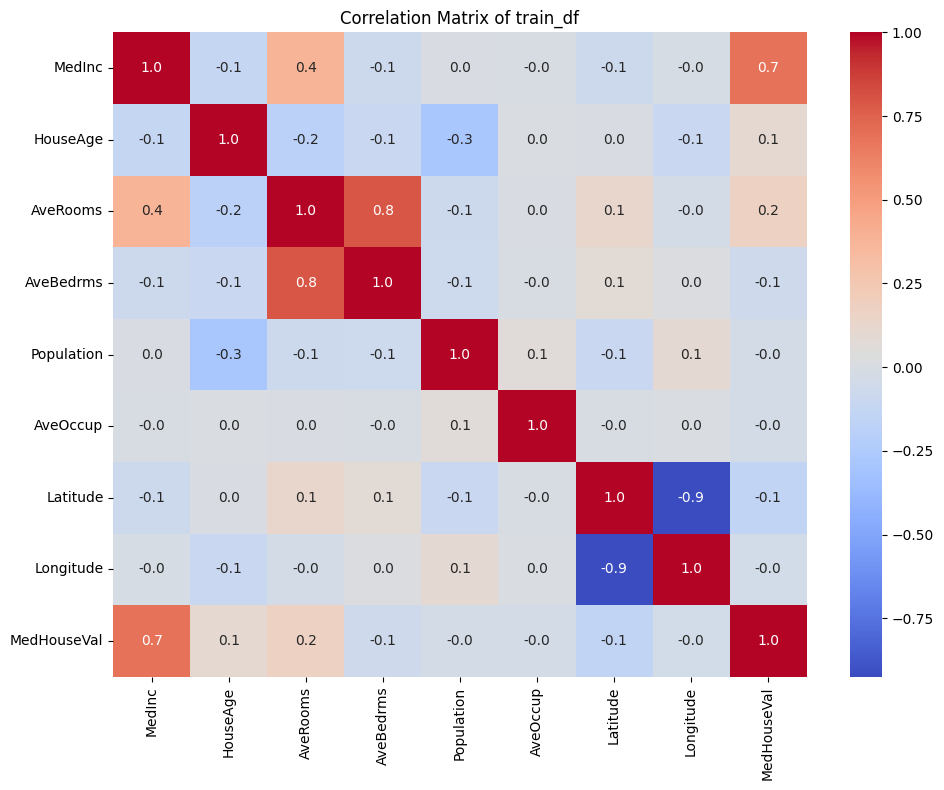

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = train_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".1f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of train_df")
plt.tight_layout()
plt.show()


# Fit a linear regression model

In [17]:
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

linear_regression_model = linear_model.LinearRegression()
linear_regression_model.fit(X_train, y_train)

y_test_pred = linear_regression_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Test MAE: {test_mae:.4f}")
print(f"Test MSE: {test_mse:.4f}")


Test MAE: 0.5335
Test MSE: 0.5545


# Fit a ridge regression model

In [18]:
ridge_regression_model = linear_model.Ridge()
ridge_regression_model.fit(X_train, y_train)

y_test_pred_ridge = ridge_regression_model.predict(X_test)
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
test_mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)

print(f"Ridge Test MAE: {test_mae_ridge:.4f}")
print(f"Ridge Test MSE: {test_mse_ridge:.4f}")


Ridge Test MAE: 0.5335
Ridge Test MSE: 0.5544


# Fit an Elastic Net regression model

In [19]:
elastic_net_regression_model = linear_model.ElasticNet()
elastic_net_regression_model.fit(X_train, y_train)

y_test_pred_elastic_net = elastic_net_regression_model.predict(X_test)
test_mae_elastic_net = mean_absolute_error(y_test, y_test_pred_elastic_net)
test_mse_elastic_net = mean_squared_error(y_test, y_test_pred_elastic_net)

print(f"Elastic Net Test MAE: {test_mae_elastic_net:.4f}")
print(f"Elastic Net Test MSE: {test_mse_elastic_net:.4f}")


Elastic Net Test MAE: 0.6765
Elastic Net Test MSE: 0.7654
